# MORDM

4 steps based on assignment 9

MORDM has four main steps:

(i)	    **problem formulation** based on a systems analytical problem definition framework

(ii)	**searching** for candidate solutions that optimize multiple objectives by using multi-objective evolutionary algorithms

(iii)	generating an ensemble of scenarios to **explore** the effects of uncertainties

(iv)	using **scenario discovery** to detect the vulnerabilities of candidate solutions and improving the candidate solutions

## Step 1: Problem formulation

In [1]:
from problem_formulation import get_model_for_problem_formulation
from ema_workbench import ema_logging, MultiprocessingEvaluator, Scenario, ScalarOutcome
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.analysis import parcoords
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
dike_model, planning_steps = get_model_for_problem_formulation(2)

# Don't minimize rfr, the costs can be as high as necessary
# Change direction only for "RfR Investment Costs"
#for outcome in dike_model.outcomes:
 #   if outcome.name == "RfR Investment Costs":
  #      outcome.kind = ScalarOutcome.INFO


# we can add expected range per outcome (dat is goed want dan houdt je zelf controle)

In [3]:
# Check if the change worked and the other directions are still minimizing
for outcome in dike_model.outcomes:
    print(f"Outcome: {outcome.name}, Direction: {outcome.kind}")

Outcome: Expected Annual Damage, Direction: -1
Outcome: Dike Investment Costs, Direction: -1
Outcome: RfR Investment Costs, Direction: -1
Outcome: Evacuation Costs, Direction: -1
Outcome: Expected Number of Deaths, Direction: -1


## Step 2: Searching for candidate solutions

In [4]:
reference_scenario = Scenario('reference', **{'discount rate 0': 2.5, 'discount rate 1': 2.5, 'discount rate 2': 2.5, 'A.0_ID flood wave shape': 75,
                                              'A.1_Bmax': 190, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
                                              'A.2_Bmax': 190, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
                                              'A.3_Bmax': 190, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
                                              'A.4_Bmax': 190, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
                                              'A.5_Bmax': 190, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

## Second attempt to convergence for 1 seed

In [6]:
from ema_workbench.em_framework.optimization import (ArchiveLogger,
                                                     EpsilonProgress)
from ema_workbench import Constraint

convergence_metrics = [ArchiveLogger(
                        "./archives",
                        [l.name for l in dike_model.levers],
                        [o.name for o in dike_model.outcomes],
                        base_filename="tutorial.tar.gz",
                        ),
                        EpsilonProgress(),
                        ]

In [ ]:
with MultiprocessingEvaluator(dike_model) as evaluator:
    results, convergence = evaluator.optimize(nfe=2500, searchover='levers',
                                    epsilons=[0.25, 0.25, 0.25, 0.25, 0.25],
                                    convergence=convergence_metrics)

  0%|                                                 | 0/2500 [00:00<?, ?it/s]

In [ ]:
from ema_workbench import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
    InvertedGenerationalDistanceMetric,
    SpacingMetric,
)
from ema_workbench.em_framework.optimization import to_problem

def calculate_metrics(archives, reference_set):
    problem = to_problem(dike_model, searchover="levers")

    hv = HypervolumeMetric(reference_set, problem)


    metrics = []
    for nfe, archive in archives.items():
        scores = {
            "hypervolume": hv.calculate(archive),
            "nfe": int(nfe)
        }
        metrics.append(scores)
    metrics = pd.DataFrame.from_dict(metrics)

    # sort metrics by number of function evaluations
    metrics.sort_values(by="nfe", inplace=True)
    return metrics


def plot_metrics(metrics, convergence):
    sns.set_style("white")
    fig, axes = plt.subplots(nrows=2, figsize=(8, 6), sharex=True)

    ax1, ax2 = axes

    ax1.plot(metrics.nfe, metrics.hypervolume)
    ax1.set_ylabel("hypervolume")

    ax2.plot(convergence.nfe, convergence.epsilon_progress)
    ax2.set_ylabel(r'$\epsilon$ progress')


In [ ]:
archives = ArchiveLogger.load_archives(f"./archives/tutorial.tar.gz")
reference_set = archives[max(archives.keys())] # this is the final archive

In [ ]:
metrics = calculate_metrics(archives, reference_set)
plot_metrics(metrics, convergence)

plt.show()

## First attempt to convergence for 5 seeds

In [5]:
# Track convergence to see the difference for 5 seeds
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
import os

ema_logging.log_to_stderr(ema_logging.INFO)

# we need to store our results for each seed
results = []
convergences = []

with MultiprocessingEvaluator(dike_model) as evaluator:
    # we run again for 1 seeds
    for i in range():
        # we create 2 covergence tracker metrics: Epsilon progress and Hypervolume
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in dike_model.levers],
                [o.name for o in dike_model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(
            nfe=1000,
            searchover="levers",
            epsilons=[0.25, 0.25, 0.25, 0.25],
            convergence=convergence_metrics,
            reference=reference_scenario
        )

        results.append(result)
        convergences.append(convergence)

[MainProcess/INFO] pool started with 18 workers
100%|██████████████████████████████████████| 1000/1000 [00:55<00:00, 18.08it/s]
[MainProcess/INFO] optimization completed, found 9 solutions
100%|██████████████████████████████████████| 1000/1000 [01:07<00:00, 14.74it/s]
[MainProcess/INFO] optimization completed, found 6 solutions
100%|██████████████████████████████████████| 1000/1000 [01:06<00:00, 14.96it/s]
[MainProcess/INFO] optimization completed, found 2 solutions
[MainProcess/INFO] terminating pool


In [6]:
results

[   0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0        0        0        0        0        0        1        1        1   
 1        0        1        0        0        0        0        1        0   
 2        1        0        1        0        0        0        1        1   
 3        0        1        0        0        0        0        1        0   
 4        1        0        1        0        1        0        1        0   
 5        0        1        0        0        0        1        0        1   
 6        0        0        0        1        0        0        1        1   
 7        1        0        1        1        1        0        1        1   
 8        0        0        0        1        1        1        0        1   
 
    2_RfR 2  3_RfR 0  ...  A.4_DikeIncrease 0  A.4_DikeIncrease 1  \
 0        1        1  ...                   3                   7   
 1        1        0  ...                   0                   0   
 2        1

In [7]:
all_archives = []

for i in range(3):
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")
    all_archives.append(archives)

In [8]:
from ema_workbench.em_framework.optimization import epsilon_nondominated, to_problem

from ema_workbench import HypervolumeMetric

from ema_workbench.em_framework.optimization import to_problem

problem = to_problem(dike_model, searchover="levers")

reference_set = epsilon_nondominated(results, [0.25] * len(dike_model.outcomes), problem)

hv = HypervolumeMetric(reference_set, problem)

metrics_by_seed = []
for archives in all_archives:
    metrics = []
    for nfe, archive in archives.items():
        scores = {
            "hypervolume": hv.calculate(archive),
            "nfe": int(nfe),
        }
        metrics.append(scores)
    metrics = pd.DataFrame.from_dict(metrics)

    # sort metrics by number of function evaluations
    metrics.sort_values(by="nfe", inplace=True)
    metrics_by_seed.append(metrics)

EMAError: Parameter names ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2'] not found in archive

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
fig, axes = plt.subplots(nrows=2, figsize=(8, 6), sharex=True)

ax1, ax2 = axes

for metrics, convergence in zip(metrics_by_seed, convergences):
    ax1.plot(metrics.nfe, metrics.hypervolume)
    ax1.set_ylabel("hypervolume")

    ax2.plot(convergence.nfe, convergence.epsilon_progress)
    ax2.set_ylabel("$\epsilon$ progress")

sns.despine(fig)

plt.show()

In [31]:
ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metric = [EpsilonProgress()]

with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.optimize(nfe=50, searchover="levers", epsilons=[0.25, 0.25, 0.25, 0.25], convergence= convergence_metric,reference=reference_scenario)

[MainProcess/INFO] pool started with 18 workers
100it [00:03, 28.05it/s]                                                       
[MainProcess/INFO] optimization completed, found 6 solutions
[MainProcess/INFO] terminating pool


In [41]:
results

(   0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0        0        1        0        1        1        1        0        1   
 1        0        1        0        1        1        0        0        0   
 2        1        0        1        1        0        1        1        0   
 3        0        0        0        1        1        1        0        1   
 4        1        0        0        1        0        1        1        0   
 5        1        1        1        1        1        1        1        0   
 
    2_RfR 2  3_RfR 0  ...  A.4_DikeIncrease 0  A.4_DikeIncrease 1  \
 0        0        0  ...                   5                   0   
 1        0        0  ...                   9                   4   
 2        0        0  ...                  10                   5   
 3        1        1  ...                   5                   2   
 4        0        1  ...                   3                   2   
 5        0        1  ...             

In [47]:
outcomes, extra_info = results
outcomes

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,1,0,1,1,1,0,1,0,0,...,5,0,8,0,3,7,3.371589e+07,4.414526e+08,1383.971629,0.005515
1,0,1,0,1,1,0,0,0,0,0,...,9,4,5,4,2,0,3.900600e+07,4.325351e+08,917.750649,0.018014
2,1,0,1,1,0,1,1,0,0,0,...,10,5,5,4,0,6,8.215505e+05,4.843041e+08,28.157105,0.000218
3,0,0,0,1,1,1,0,1,1,1,...,5,2,0,1,3,5,7.626974e+06,4.739708e+08,325.051632,0.001049
4,1,0,0,1,0,1,1,0,0,1,...,3,2,6,6,0,9,1.124620e+07,4.608382e+08,478.207195,0.001559
5,1,1,1,1,1,1,1,0,0,1,...,6,10,2,9,0,6,0.000000e+00,5.039023e+08,0.000000,0.000000


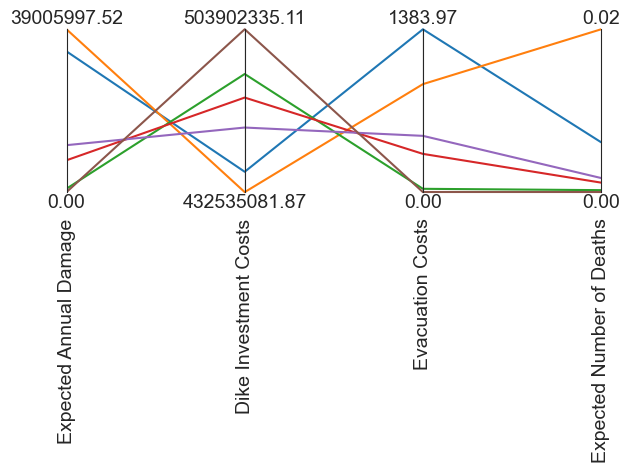

In [50]:
outcomes = outcomes.loc[:, ['Expected Annual Damage', 'Dike Investment Costs', 'Evacuation Costs', 'Expected Number of Deaths']]

limits = parcoords.get_limits(outcomes)
axes = parcoords.ParallelAxes(limits)
axes.plot(outcomes)

plt.show()

## Step 3: Re-evaluate candidate solutions under uncertainty

## Step 4: Using scenario discovery to detect the vulnerabilities of the candidate solutions and improving the candidate solutions